# Temperature Data Processing and Visualization

This notebook prepares the raw hourly Open-Meteo weather data for next-day temperature prediction. It stops before model selection and focuses on data quality, feature engineering, splitting, and exploratory visualization.

## 1. Imports and Settings

In [74]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "ggplot")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 80)

## 2. Load Raw Data

The first three rows in the CSV are metadata, so the actual table starts after `skiprows=3`.

In [75]:
DATA_PATH = Path("data/open-meteo-21.05N105.81E18m.csv")

raw_df = pd.read_csv(DATA_PATH, skiprows=3)
print(f"Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]:,} columns")
raw_df.head()

Raw shape: 52,608 rows x 11 columns


,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),cloud_cover (%),pressure_msl (hPa),surface_pressure (hPa),wind_speed_10m (km/h),wind_direction_10m (°),shortwave_radiation (W/m²)
0,2020-01-01 00:00,19.5,93,0.4,0.4,100,1024.1,1022.0,4.6,219,0.0
1,2020-01-01 01:00,19.4,93,0.3,0.3,100,1023.9,1021.8,4.6,252,0.0
2,2020-01-01 02:00,19.2,94,0.1,0.1,100,1023.4,1021.3,4.0,270,0.0
3,2020-01-01 03:00,19.1,94,0.1,0.1,100,1023.4,1021.2,3.1,306,0.0
4,2020-01-01 04:00,18.9,94,0.1,0.1,99,1023.3,1021.1,5.4,340,0.0


In [76]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   time                        52608 non-null  object 
 1   temperature_2m (°C)         52608 non-null  float64
 2   relative_humidity_2m (%)    52608 non-null  int64  
 3   precipitation (mm)          52608 non-null  float64
 4   rain (mm)                   52608 non-null  float64
 5   cloud_cover (%)             52608 non-null  int64  
 6   pressure_msl (hPa)          52608 non-null  float64
 7   surface_pressure (hPa)      52608 non-null  float64
 8   wind_speed_10m (km/h)       52608 non-null  float64
 9   wind_direction_10m (°)      52608 non-null  int64  
 10  shortwave_radiation (W/m²)  52608 non-null  float64
dtypes: float64(7), int64(3), object(1)
memory usage: 4.4+ MB


## 3. Standardize Columns

Use ASCII column names so later feature engineering and modeling code is easier to maintain.

In [77]:
column_map = {
    "temperature_2m (°C)": "temperature_2m_c",
    "relative_humidity_2m (%)": "relative_humidity_2m_pct",
    "rain (mm)": "rain_mm",
    "precipitation (mm)": "precipitation_mm",
    "pressure_msl (hPa)": "pressure_msl_hpa",
    "cloud_cover (%)": "cloud_cover_pct",
    "wind_speed_10m (km/h)": "wind_speed_10m_kmh",
    "shortwave_radiation (W/m²)": "shortwave_radiation_w_m2",
    "pressure_msl_spread (hPa)": "pressure_msl_spread_hpa",
    "surface_pressure (hPa)": "surface_pressure_hpa",
    "wind_direction_10m (°)": "wind_direction_10m_deg",
}

df = raw_df.rename(columns=column_map).copy()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

df.head()

,time,temperature_2m_c,relative_humidity_2m_pct,precipitation_mm,rain_mm,cloud_cover_pct,pressure_msl_hpa,surface_pressure_hpa,wind_speed_10m_kmh,wind_direction_10m_deg,shortwave_radiation_w_m2
0,2020-01-01 00:00:00,19.5,93,0.4,0.4,100,1024.1,1022.0,4.6,219,0.0
1,2020-01-01 01:00:00,19.4,93,0.3,0.3,100,1023.9,1021.8,4.6,252,0.0
2,2020-01-01 02:00:00,19.2,94,0.1,0.1,100,1023.4,1021.3,4.0,270,0.0
3,2020-01-01 03:00:00,19.1,94,0.1,0.1,100,1023.4,1021.2,3.1,306,0.0
4,2020-01-01 04:00:00,18.9,94,0.1,0.1,99,1023.3,1021.1,5.4,340,0.0


## 4. Data Quality Checks

In [78]:
missing_summary = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
    .sort_values("missing_count", ascending=False)
)

print(f"Duplicate timestamps: {df['time'].duplicated().sum():,}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}")
missing_summary

Duplicate timestamps: 0
Date range: 2020-01-01 00:00:00 to 2025-12-31 23:00:00


,missing_count,missing_pct
time,0,0.0
temperature_2m_c,0,0.0
relative_humidity_2m_pct,0,0.0
precipitation_mm,0,0.0
rain_mm,0,0.0
cloud_cover_pct,0,0.0
pressure_msl_hpa,0,0.0
surface_pressure_hpa,0,0.0
wind_speed_10m_kmh,0,0.0
wind_direction_10m_deg,0,0.0


In [79]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m_c,52608.0,24.246966,5.552827,6.5,20.4,25.1,28.2,41.2
relative_humidity_2m_pct,52608.0,79.299859,14.363258,22.0,70.0,82.0,91.0,100.0
precipitation_mm,52608.0,0.254049,1.062849,0.0,0.0,0.0,0.1,26.4
rain_mm,52608.0,0.254049,1.062849,0.0,0.0,0.0,0.1,26.4
cloud_cover_pct,52608.0,73.788948,36.604020,0.0,45.0,99.0,100.0,100.0
pressure_msl_hpa,52608.0,1011.160407,7.391028,983.9,1005.1,1010.7,1016.9,1034.6
surface_pressure_hpa,52608.0,1009.071358,7.341303,981.9,1003.0,1008.6,1014.8,1032.4
wind_speed_10m_kmh,52608.0,9.217687,4.566850,0.0,5.8,8.7,12.1,60.7
wind_direction_10m_deg,52608.0,139.593598,96.411323,1.0,60.0,135.0,168.0,360.0
shortwave_radiation_w_m2,52608.0,161.248479,235.437590,0.0,0.0,6.0,274.0,949.0


Drop columns that contain no signal for modeling. In this dataset, `pressure_msl_spread_hpa` is entirely missing.

In [80]:
all_missing_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_missing_cols)

print("Dropped all-missing columns:", all_missing_cols)
print(f"Clean base shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

Dropped all-missing columns: []
Clean base shape: 52,608 rows x 11 columns


## 5. Visualize Raw Hourly Patterns

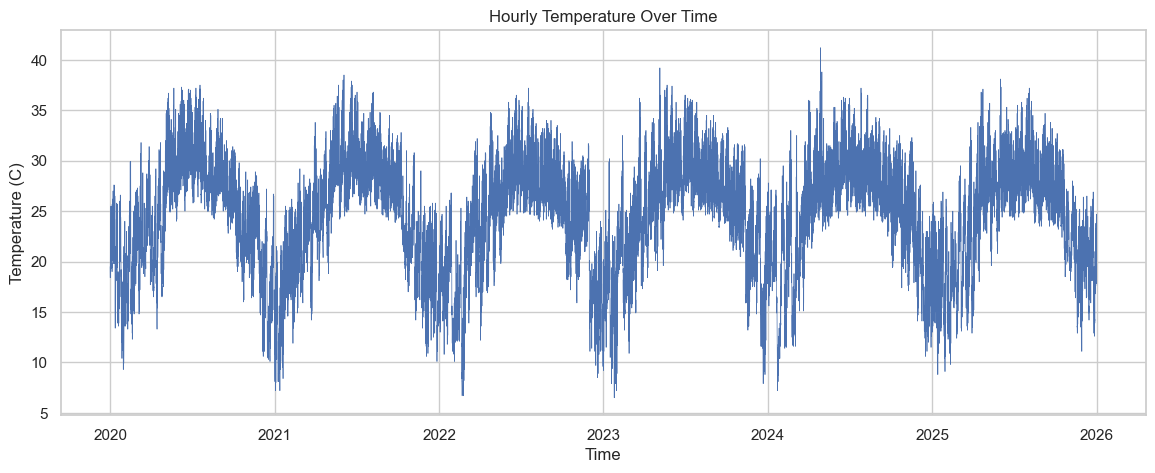

In [81]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["time"], df["temperature_2m_c"], linewidth=0.5)
ax.set_title("Hourly Temperature Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (C)")
plt.show()

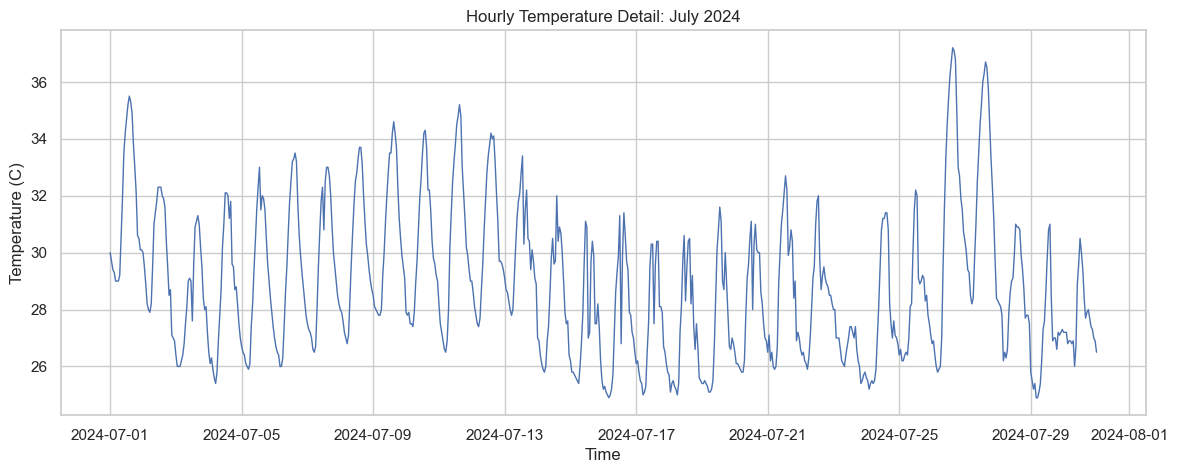

In [82]:
sample_month = df[df["time"].between("2024-07-01", "2024-07-31")]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample_month["time"], sample_month["temperature_2m_c"], linewidth=1)
ax.set_title("Hourly Temperature Detail: July 2024")
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (C)")
plt.show()

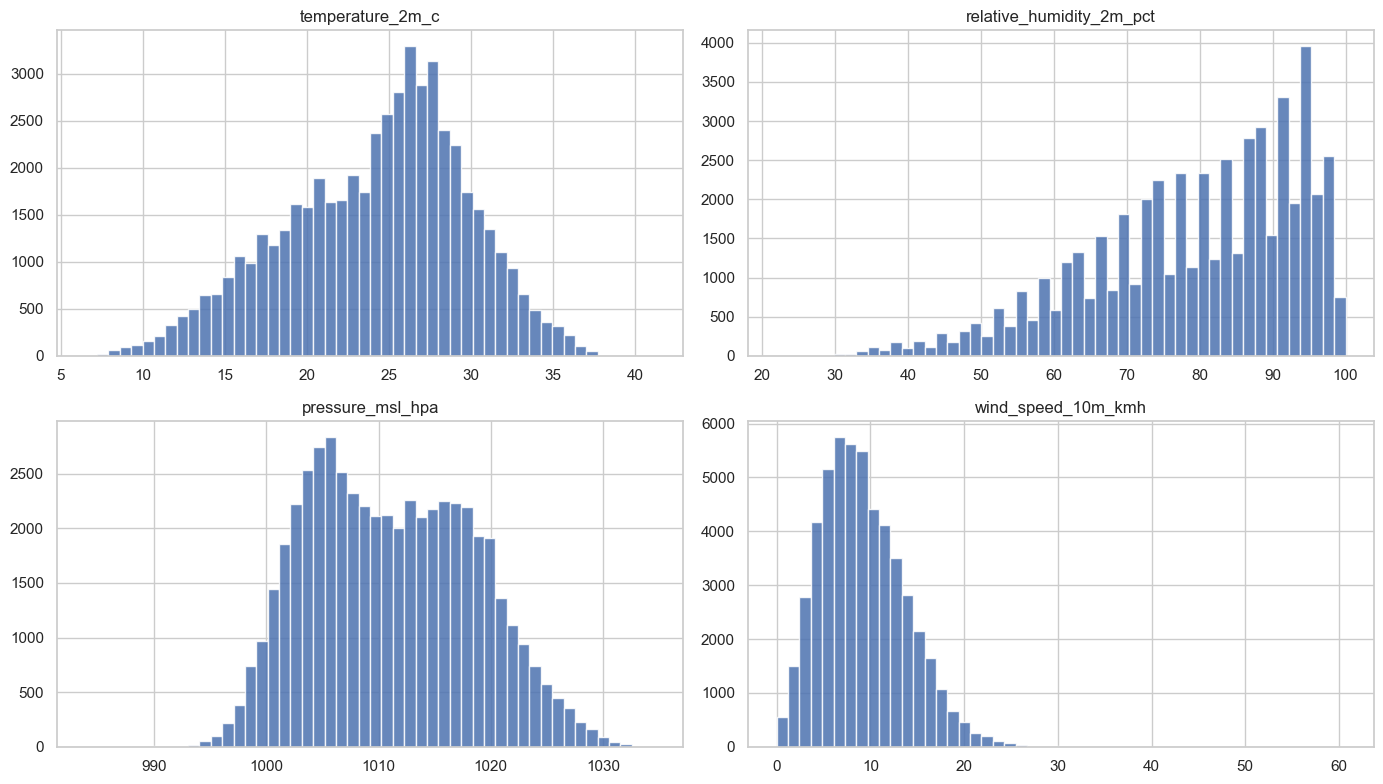

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_cols = [
    "temperature_2m_c",
    "relative_humidity_2m_pct",
    "pressure_msl_hpa",
    "wind_speed_10m_kmh",
]

for ax, col in zip(axes.ravel(), plot_cols):
    ax.hist(df[col], bins=50, alpha=0.85)
    ax.set_title(col)

plt.tight_layout()
plt.show()

## 6. Feature Engineering

Create time features, circular wind direction features, rolling 24-hour context, lag features, and the 24-hour-ahead target.

In [84]:
def add_time_features(data: pd.DataFrame) -> pd.DataFrame:
    result = data.copy()
    result["hour"] = result["time"].dt.hour
    result["dayofyear"] = result["time"].dt.dayofyear
    result["month"] = result["time"].dt.month
    result["year"] = result["time"].dt.year
    result["season"] = result["month"].map({
        12: "winter", 1: "winter", 2: "winter",
        3: "spring", 4: "spring", 5: "spring",
        6: "summer", 7: "summer", 8: "summer",
        9: "autumn", 10: "autumn", 11: "autumn",
    })
    return result


def add_weather_features(data: pd.DataFrame) -> pd.DataFrame:
    result = data.copy()

    wind_rad = np.deg2rad(result["wind_direction_10m_deg"])
    result["wind_dir_sin"] = np.sin(wind_rad)
    result["wind_dir_cos"] = np.cos(wind_rad)

    result["temp_max_24h"] = result["temperature_2m_c"].rolling(window=24, min_periods=24).max()
    result["temp_min_24h"] = result["temperature_2m_c"].rolling(window=24, min_periods=24).min()
    result["temp_mean_24h"] = result["temperature_2m_c"].rolling(window=24, min_periods=24).mean()
    result["total_rain_24h"] = result["rain_mm"].rolling(window=24, min_periods=24).sum()
    result["humidity_mean_24h"] = result["relative_humidity_2m_pct"].rolling(window=24, min_periods=24).mean()

    result["temp_lag_24h"] = result["temperature_2m_c"].shift(24)
    result["pressure_lag_24h"] = result["pressure_msl_hpa"].shift(24)
    result["target_temp_24h"] = result["temperature_2m_c"].shift(-24)

    return result


feature_df = df.pipe(add_time_features).pipe(add_weather_features)
feature_df.head(30).tail()

,time,temperature_2m_c,relative_humidity_2m_pct,precipitation_mm,rain_mm,cloud_cover_pct,pressure_msl_hpa,surface_pressure_hpa,wind_speed_10m_kmh,wind_direction_10m_deg,shortwave_radiation_w_m2,hour,dayofyear,month,year,season,wind_dir_sin,wind_dir_cos,temp_max_24h,temp_min_24h,temp_mean_24h,total_rain_24h,humidity_mean_24h,temp_lag_24h,pressure_lag_24h,target_temp_24h
25,2020-01-02 01:00:00,18.6,95,0.0,0.0,99,1023.1,1020.9,3.8,163,0.0,1,2,1,2020,winter,0.292372,-0.956305,23.0,18.4,19.900000,3.6,87.000000,19.4,1023.9,20.0
26,2020-01-02 02:00:00,19.0,95,0.0,0.0,100,1022.7,1020.5,2.1,149,0.0,2,2,1,2020,winter,0.515038,-0.857167,23.0,18.4,19.891667,3.5,87.041667,19.2,1023.4,20.0
27,2020-01-02 03:00:00,19.0,92,0.0,0.0,100,1022.3,1020.2,2.4,63,0.0,3,2,1,2020,winter,0.891007,0.453990,23.0,18.4,19.887500,3.4,86.958333,19.1,1023.4,19.9
28,2020-01-02 04:00:00,19.0,93,0.0,0.0,99,1022.3,1020.2,3.3,77,0.0,4,2,1,2020,winter,0.974370,0.224951,23.0,18.4,19.891667,3.3,86.916667,18.9,1023.3,20.0
29,2020-01-02 05:00:00,19.2,92,0.0,0.0,100,1022.4,1020.3,4.0,85,0.0,5,2,1,2020,winter,0.996195,0.087156,23.0,18.4,19.920833,3.3,86.833333,18.5,1023.2,20.0


Filter to one record per day at 12:00. This matches the prediction notebook: each row represents conditions at noon and predicts temperature at noon the next day.

In [85]:
daily_df = (
    feature_df
    .dropna()
    .loc[lambda x: x["hour"] == 12]
    .reset_index(drop=True)
)

print(f"Daily modeling shape: {daily_df.shape[0]:,} rows x {daily_df.shape[1]:,} columns")
daily_df[["time", "temperature_2m_c", "temp_lag_24h", "target_temp_24h", "season"]].head()

Daily modeling shape: 2,190 rows x 26 columns


,time,temperature_2m_c,temp_lag_24h,target_temp_24h,season
0,2020-01-02 12:00:00,23.0,22.4,23.0,winter
1,2020-01-03 12:00:00,23.0,23.0,22.5,winter
2,2020-01-04 12:00:00,22.5,23.0,25.2,winter
3,2020-01-05 12:00:00,25.2,22.5,25.8,winter
4,2020-01-06 12:00:00,25.8,25.2,26.0,winter


## 7. Visualize Engineered Daily Data

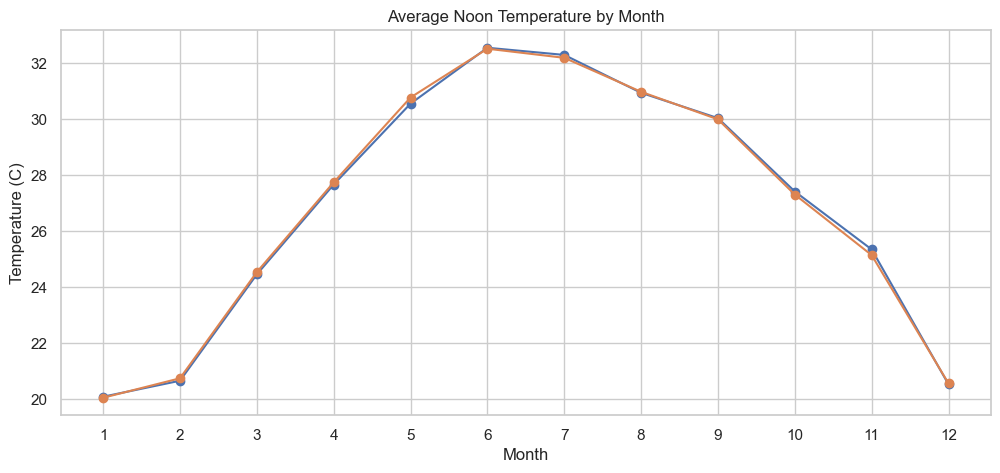

,month,avg_current_temp,avg_target_temp,avg_humidity,avg_rain_24h
0,1,20.092432,20.055676,60.810811,1.664324
1,2,20.662941,20.750000,69.088235,2.430000
2,3,24.459677,24.540860,69.166667,2.681183
3,4,27.667778,27.745556,68.783333,3.161667
4,5,30.555376,30.774731,69.575269,7.043011
5,6,32.551111,32.516667,67.061111,10.105000
6,7,32.295161,32.191935,69.161290,9.465054
7,8,30.942473,30.977957,74.784946,12.463978
8,9,30.037222,29.994444,74.183333,13.792778
9,10,27.418817,27.309140,64.532258,7.479032


In [86]:
monthly_profile = (
    daily_df.groupby("month", as_index=False)
    .agg(
        avg_current_temp=("temperature_2m_c", "mean"),
        avg_target_temp=("target_temp_24h", "mean"),
        avg_humidity=("relative_humidity_2m_pct", "mean"),
        avg_rain_24h=("total_rain_24h", "mean"),
    )
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_profile["month"], monthly_profile["avg_current_temp"], marker="o", label="Current noon temp")
ax.plot(monthly_profile["month"], monthly_profile["avg_target_temp"], marker="o", label="Next-day noon temp")
ax.set_title("Average Noon Temperature by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Temperature (C)")
ax.set_xticks(range(1, 13))
plt.show()

monthly_profile

C:\Users\tinta\AppData\Local\Temp\ipykernel_2256\304434422.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=season_order, patch_artist=True)


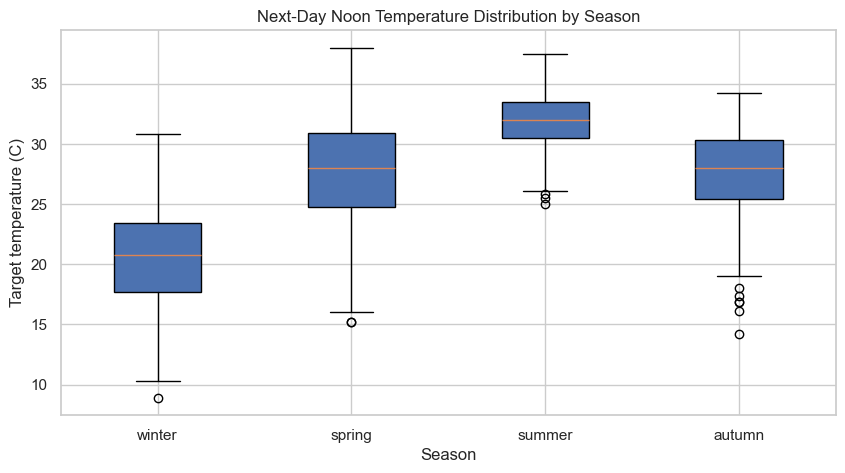

In [87]:
season_order = ["winter", "spring", "summer", "autumn"]
box_data = [daily_df.loc[daily_df["season"] == season, "target_temp_24h"] for season in season_order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(box_data, labels=season_order, patch_artist=True)
ax.set_title("Next-Day Noon Temperature Distribution by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Target temperature (C)")
plt.show()

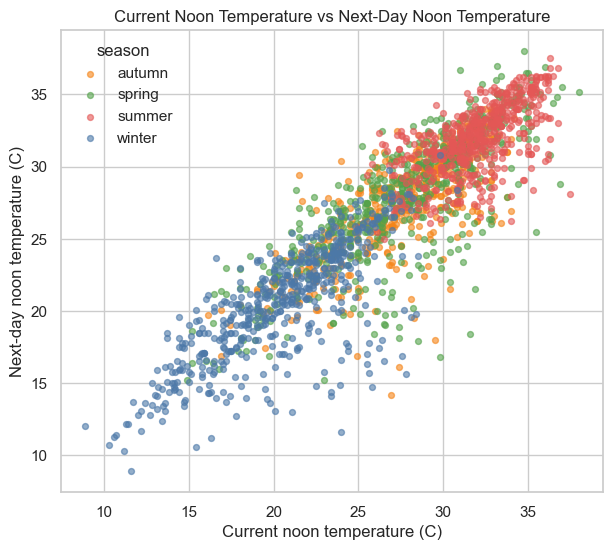

In [88]:
plot_sample = daily_df.sample(min(3000, len(daily_df)), random_state=42)
season_colors = {"winter": "#4C78A8", "spring": "#54A24B", "summer": "#E45756", "autumn": "#F58518"}

fig, ax = plt.subplots(figsize=(7, 6))
for season, season_data in plot_sample.groupby("season"):
    ax.scatter(
        season_data["temperature_2m_c"],
        season_data["target_temp_24h"],
        label=season,
        alpha=0.6,
        s=18,
        color=season_colors.get(season),
    )
ax.set_title("Current Noon Temperature vs Next-Day Noon Temperature")
ax.set_xlabel("Current noon temperature (C)")
ax.set_ylabel("Next-day noon temperature (C)")
ax.legend(title="season")
plt.show()

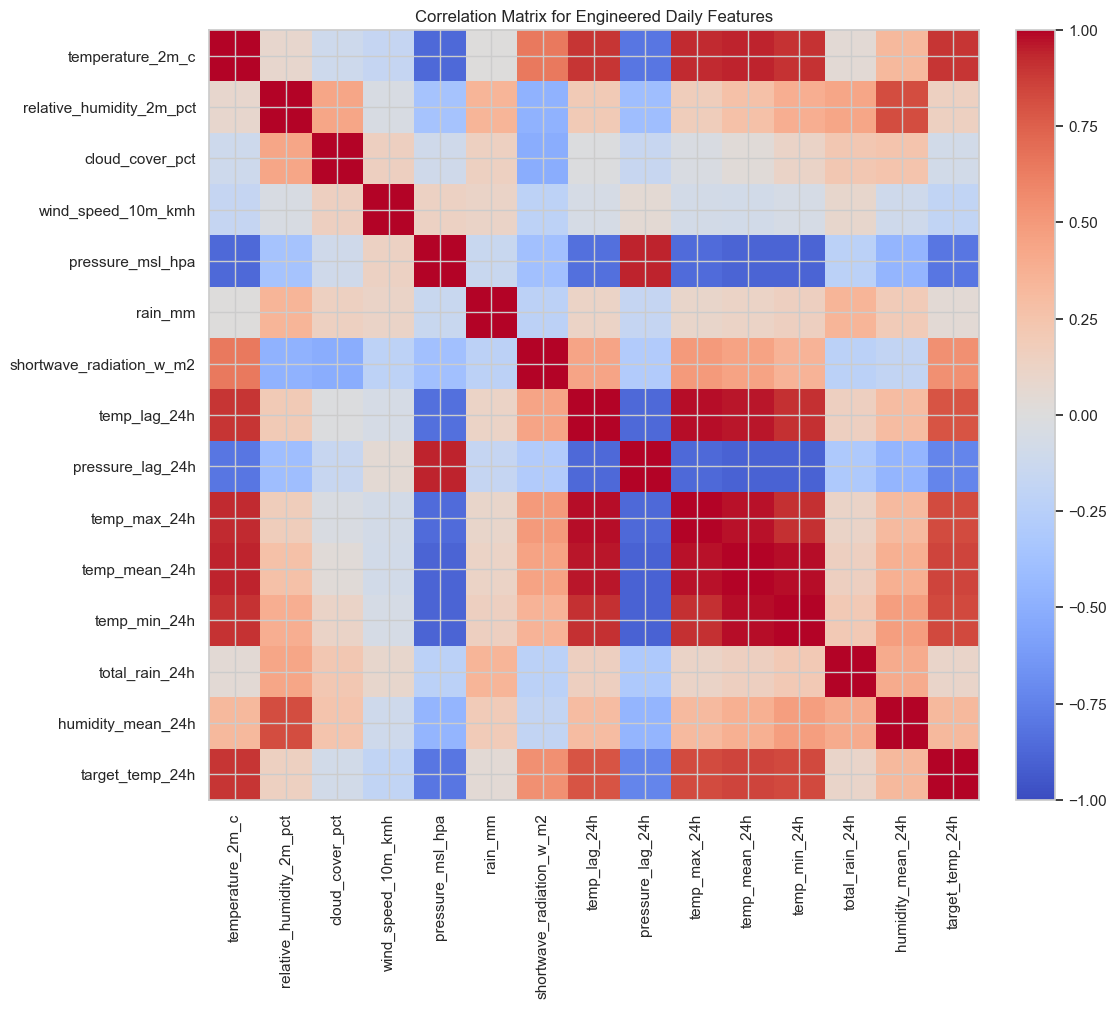

target_temp_24h             1.000000
temperature_2m_c            0.892348
temp_mean_24h               0.851431
temp_min_24h                0.830316
temp_max_24h                0.825196
temp_lag_24h                0.795408
shortwave_radiation_w_m2    0.545261
humidity_mean_24h           0.323843
relative_humidity_2m_pct    0.141256
total_rain_24h              0.105400
rain_mm                     0.041840
cloud_cover_pct            -0.080573
wind_speed_10m_kmh         -0.193474
pressure_lag_24h           -0.728100
pressure_msl_hpa           -0.798010
Name: target_temp_24h, dtype: float64

In [89]:
corr_cols = [
    "temperature_2m_c",
    "relative_humidity_2m_pct",
    "cloud_cover_pct",
    "wind_speed_10m_kmh",
    "pressure_msl_hpa",
    "rain_mm",
    "shortwave_radiation_w_m2",
    "temp_lag_24h",
    "pressure_lag_24h",
    "temp_max_24h",
    "temp_mean_24h",
    "temp_min_24h",
    "total_rain_24h",
    "humidity_mean_24h",
    "target_temp_24h",
]

corr = daily_df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation Matrix for Engineered Daily Features")
plt.show()

corr["target_temp_24h"].sort_values(ascending=False)

## 8. Define Features and Time-Based Splits

Use chronological splits to avoid leakage: train on 2000-2023, validate on 2024, and test on 2025.

In [90]:
features = [
    "temperature_2m_c",
    "relative_humidity_2m_pct",
    "cloud_cover_pct",
    "wind_speed_10m_kmh",
    "pressure_msl_hpa",
    "rain_mm",
    "dayofyear",
    "month",
    "season",
    "temp_lag_24h",
    "pressure_lag_24h",
    "wind_dir_sin",
    "wind_dir_cos",
    "temp_max_24h",
    "temp_mean_24h",
    "temp_min_24h",
    "total_rain_24h",
    "humidity_mean_24h",
    "shortwave_radiation_w_m2",
]
target = "target_temp_24h"

train_mask = daily_df["year"].between(2020, 2023)
val_mask = daily_df["year"].eq(2024)
test_mask = daily_df["year"].eq(2025)

X_train = daily_df.loc[train_mask, features]
y_train = daily_df.loc[train_mask, target]
X_val = daily_df.loc[val_mask, features]
y_val = daily_df.loc[val_mask, target]
X_test = daily_df.loc[test_mask, features]
y_test = daily_df.loc[test_mask, target]

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "years": ["2000-2023", "2024", "2025"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "target_mean": [y_train.mean(), y_val.mean(), y_test.mean()],
    "target_std": [y_train.std(), y_val.std(), y_test.std()],
})

split_summary

,split,years,rows,target_mean,target_std
0,train,2000-2023,1460,26.818356,5.539546
1,validation,2024,366,27.404918,5.513568
2,test,2025,364,26.779670,5.300535


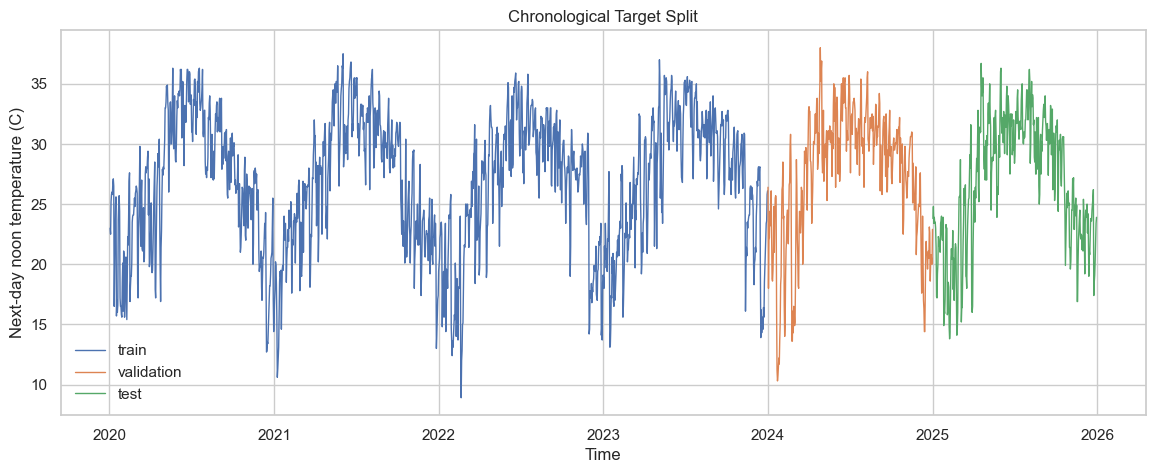

In [91]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_df.loc[train_mask, "time"], daily_df.loc[train_mask, target], label="train", linewidth=1)
ax.plot(daily_df.loc[val_mask, "time"], daily_df.loc[val_mask, target], label="validation", linewidth=1)
ax.plot(daily_df.loc[test_mask, "time"], daily_df.loc[test_mask, target], label="test", linewidth=1)
ax.set_title("Chronological Target Split")
ax.set_xlabel("Time")
ax.set_ylabel("Next-day noon temperature (C)")
ax.legend()
plt.show()

## 9. Report-Ready EDA and PCA

The following cells use a DataFrame named `data`, matching the report requirement. In this notebook, `data` is created from the raw loaded dataset. If you already loaded a DataFrame named `data` elsewhere, these cells can run with that DataFrame directly.

In [92]:
# Use the original project column names for this EDA/PCA section.
data = raw_df.copy()

# Convert time to datetime and create calendar features used in visual analysis.
data["time"] = pd.to_datetime(data["time"], errors="coerce")
data = data.sort_values("time").reset_index(drop=True)
data["month"] = data["time"].dt.month

temperature_col = "temperature_2m (°C)"
rain_col = "rain (mm)"

print(f"EDA dataset shape: {data.shape[0]:,} rows x {data.shape[1]:,} columns")
data[["time", temperature_col, rain_col, "month"]].head()

EDA dataset shape: 52,608 rows x 12 columns


,time,temperature_2m (°C),rain (mm),month
0,2020-01-01 00:00:00,19.5,0.4,1
1,2020-01-01 01:00:00,19.4,0.3,1
2,2020-01-01 02:00:00,19.2,0.1,1
3,2020-01-01 03:00:00,19.1,0.1,1
4,2020-01-01 04:00:00,18.9,0.1,1


### 9.1 Temperature Trend Over Time

This line plot shows long-term temperature movement and seasonal cycles. It helps reveal recurring annual patterns, unusual periods, and whether the raw time series is chronologically consistent before model selection.

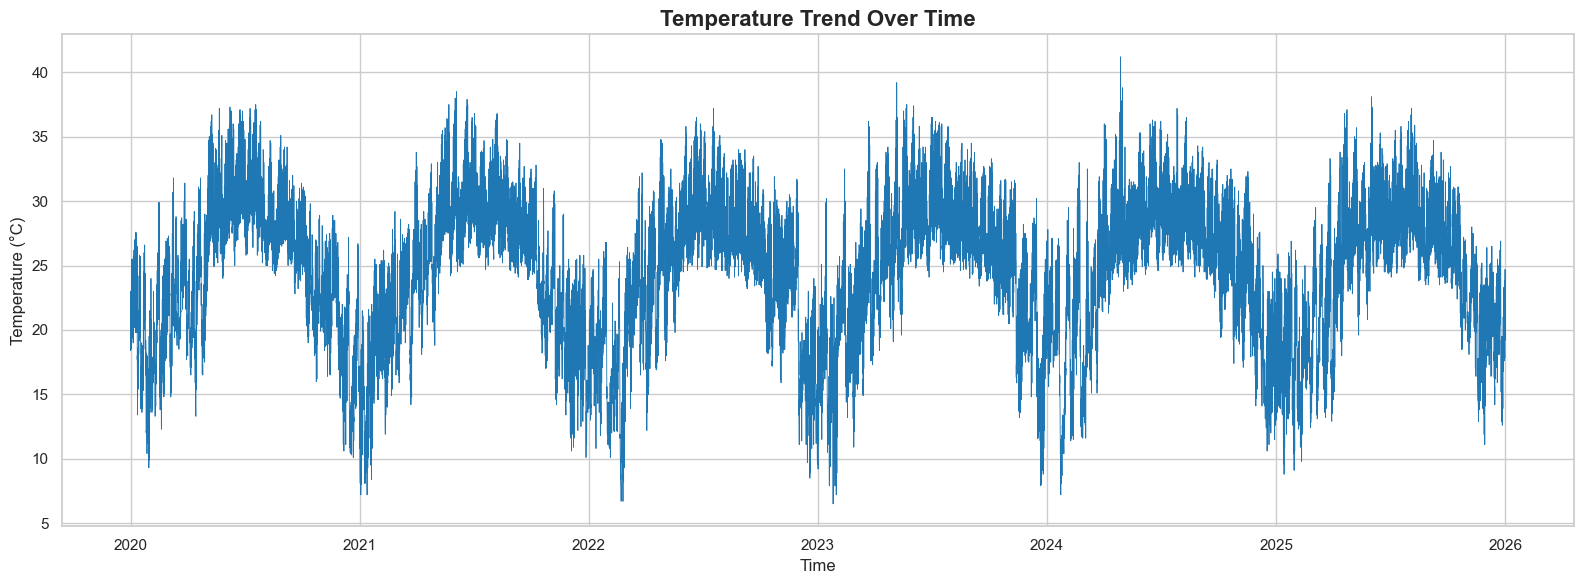

In [93]:
plt.figure(figsize=(16, 6))
plt.plot(data["time"], data[temperature_col], color="#1f77b4", linewidth=0.6)
plt.title("Temperature Trend Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Time", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.tight_layout()
plt.show()

### 9.2 Temperature Distribution Histogram

The histogram summarizes the frequency of observed temperatures. It reveals the typical temperature range, skewness, spread, and whether extreme hot or cool values are common enough to influence regression models.

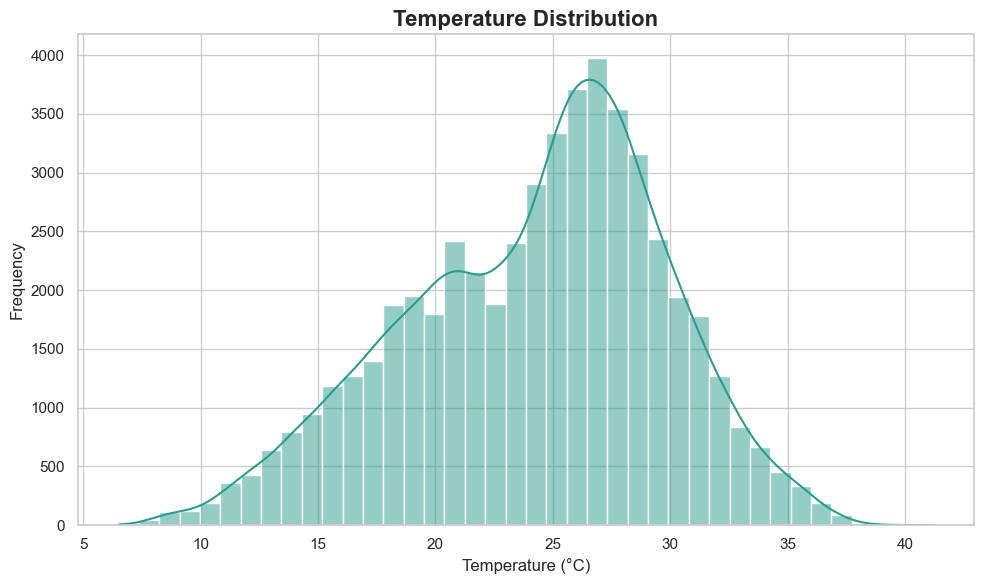

In [94]:
plt.figure(figsize=(10, 6))
if sns is not None:
    sns.histplot(data=data, x=temperature_col, bins=40, kde=True, color="#2a9d8f")
else:
    plt.hist(data[temperature_col].dropna(), bins=40, color="#2a9d8f", alpha=0.85)
plt.title("Temperature Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Temperature (°C)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

### 9.3 Monthly Average Temperature

Monthly averages reveal the seasonal temperature profile. This plot is useful for showing that month and day-of-year features can carry meaningful predictive information for next-day temperature forecasting.

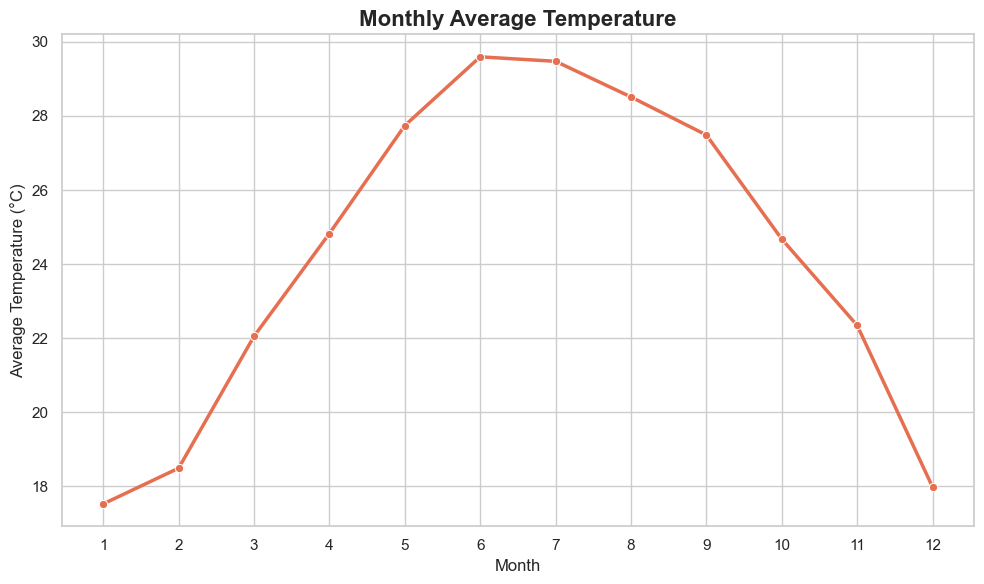

,month,avg_temperature_c
0,1,17.525269
1,2,18.489804
2,3,22.050314
3,4,24.825718
4,5,27.740547
5,6,29.596042
6,7,29.474686
7,8,28.512590
8,9,27.485324
9,10,24.675470


In [95]:
monthly_temperature = (
    data.groupby("month", as_index=False)[temperature_col]
    .mean()
    .rename(columns={temperature_col: "avg_temperature_c"})
)

plt.figure(figsize=(10, 6))
if sns is not None:
    sns.lineplot(data=monthly_temperature, x="month", y="avg_temperature_c", marker="o", linewidth=2.5, color="#e76f51")
else:
    plt.plot(monthly_temperature["month"], monthly_temperature["avg_temperature_c"], marker="o", linewidth=2.5, color="#e76f51")
plt.title("Monthly Average Temperature", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Temperature (°C)", fontsize=12)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

monthly_temperature

### 9.4 Monthly Rainfall Distribution

Rainfall distribution by month shows wet and dry seasonal behavior. This matters because rain and humidity can affect temperature changes and may improve regression performance when included as weather predictors.

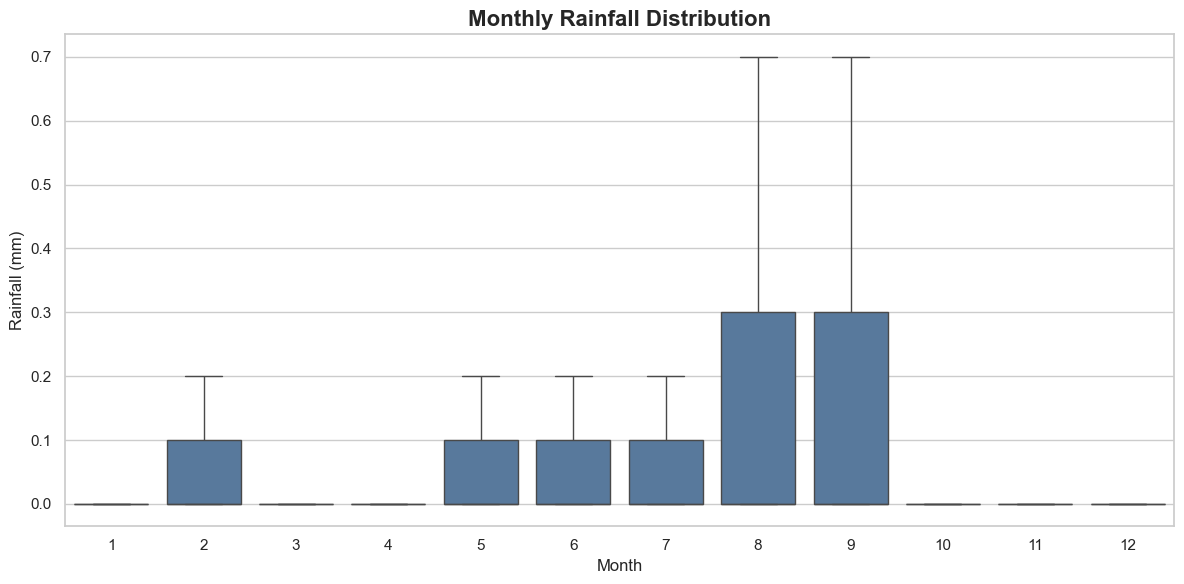

In [96]:
plt.figure(figsize=(12, 6))
if sns is not None:
    sns.boxplot(data=data, x="month", y=rain_col, color="#4c78a8", showfliers=False)
else:
    rainfall_by_month = [data.loc[data["month"] == month, rain_col].dropna() for month in range(1, 13)]
    plt.boxplot(rainfall_by_month, labels=range(1, 13), showfliers=False, patch_artist=True)
plt.title("Monthly Rainfall Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Rainfall (mm)", fontsize=12)
plt.tight_layout()
plt.show()

### 9.5 Correlation Heatmap

The correlation heatmap shows linear relationships among numerical weather variables. It helps identify strongly related predictors, potential multicollinearity, and variables most directly associated with temperature.

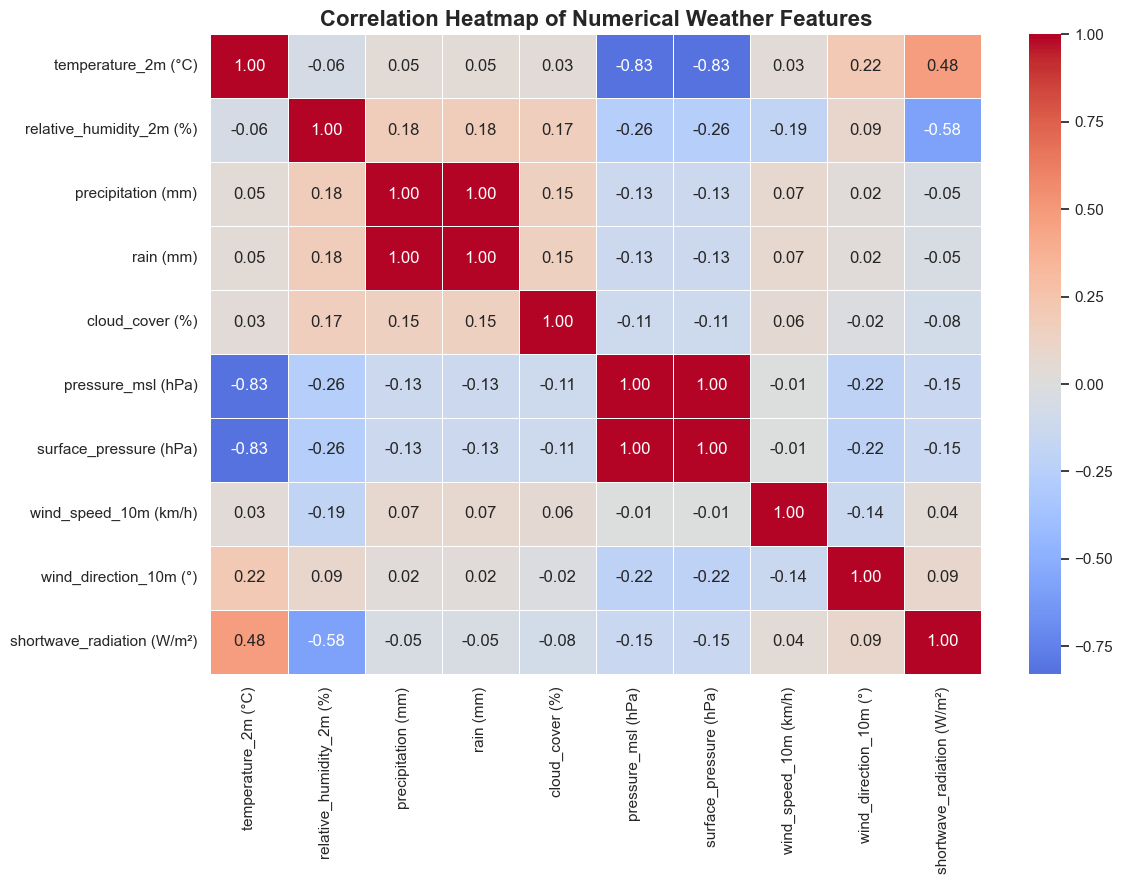

In [97]:
weather_numeric_features = [
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "precipitation (mm)",
    "rain (mm)",
    "cloud_cover (%)",
    "pressure_msl (hPa)",
    "surface_pressure (hPa)",
    "wind_speed_10m (km/h)",
    "wind_direction_10m (°)",
    "shortwave_radiation (W/m²)",
]

corr_data = data[weather_numeric_features].dropna()
corr_matrix = corr_data.corr()

plt.figure(figsize=(12, 9))
if sns is not None:
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
else:
    plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
    plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Heatmap of Numerical Weather Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### 9.6 PCA 2D Visualization for Cool, Normal, and Hot Temperature Classes

PCA projects standardized numerical weather features into two components. Coloring the points by temperature class helps show whether cool, normal, and hot observations form distinct weather regimes. Clear separation suggests the weather variables contain structure related to temperature; overlap suggests transitions are gradual and regression models must learn continuous relationships rather than simple class boundaries.

In [98]:
pca_data = data[weather_numeric_features].copy()
pca_data["temperature_class"] = pd.cut(
    data[temperature_col],
    bins=[-np.inf, 20, 30, np.inf],
    labels=["Cool", "Normal", "Hot"],
    right=False,
)

# Remove rows with missing PCA features or missing class labels.
pca_data = pca_data.dropna(subset=weather_numeric_features + ["temperature_class"])

X_pca = pca_data[weather_numeric_features]
y_class = pca_data["temperature_class"]

# Standardization is required because PCA is sensitive to feature scale.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(X_scaled)

pca_plot_df = pd.DataFrame({
    "PC1": principal_components[:, 0],
    "PC2": principal_components[:, 1],
    "temperature_class": y_class.to_numpy(),
})

print("Explained variance ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")

Explained variance ratio:
PC1: 0.3052
PC2: 0.2146
Total explained variance: 0.5198


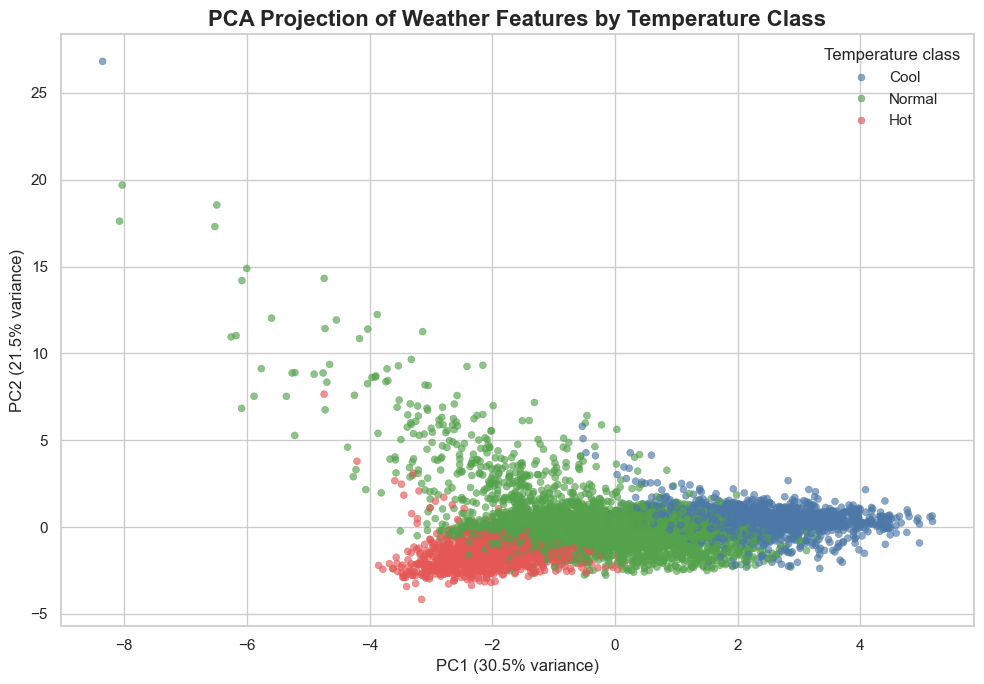

In [99]:
# Plot a reproducible sample to keep the figure readable for the report.
pca_sample = pca_plot_df.sample(min(8000, len(pca_plot_df)), random_state=42)
class_order = ["Cool", "Normal", "Hot"]
class_palette = {"Cool": "#4c78a8", "Normal": "#54a24b", "Hot": "#e45756"}

plt.figure(figsize=(10, 7))
if sns is not None:
    sns.scatterplot(
        data=pca_sample,
        x="PC1",
        y="PC2",
        hue="temperature_class",
        hue_order=class_order,
        palette=class_palette,
        alpha=0.65,
        s=25,
        edgecolor=None,
    )
else:
    for class_name in class_order:
        class_data = pca_sample[pca_sample["temperature_class"] == class_name]
        plt.scatter(class_data["PC1"], class_data["PC2"], label=class_name, color=class_palette[class_name], alpha=0.65, s=25)
plt.title("PCA Projection of Weather Features by Temperature Class", fontsize=16, fontweight="bold")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)", fontsize=12)
plt.legend(title="Temperature class")
plt.tight_layout()
plt.show()

**EDA and PCA interpretation:** The trend, monthly temperature, and rainfall plots show the dataset has strong seasonal structure, which supports using calendar and weather-context features for 24-hour-ahead forecasting. The temperature histogram shows the most common temperature range and the balance between cool, normal, and hot conditions. The correlation heatmap highlights redundant or related variables, such as pressure measures or rainfall measures, which is useful before model selection. The PCA scatter plot compresses the numerical weather variables into two dimensions; if Hot, Normal, and Cool observations occupy different regions, the weather features contain meaningful structure associated with temperature regimes. If the classes overlap, the temperature behavior is more continuous, so regression models should be evaluated carefully rather than relying on simple class separation.

## 10. Save Processed Data

Save the processed daily dataset so model-selection notebooks can start from the same clean data.

In [100]:
OUTPUT_PATH = Path("data/processed_daily_temperature.csv")
daily_df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved processed dataset to {OUTPUT_PATH}")
print(f"Rows: {len(daily_df):,}")
print(f"Feature count: {len(features):,}")

Saved processed dataset to data\processed_daily_temperature.csv
Rows: 2,190
Feature count: 19
